Task 1.1 — Dataset Exploration (Completed)
* Load dataset
* Print keys
* Print shapes
* Print data types
* Inspect unique labels
* Explain that there is no metadata to filter

In [1]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\mahak\OneDrive\Desktop\ISRO
['.git', 'DSRSID.mat', 'main.ipynb', 'README.md']


In [2]:
import h5py

f = h5py.File("DSRSID.mat", "r")
print(list(f.keys()))

['LAND_COVER_TYPES', 'MUL_IMAGES', 'PAN_IMAGES']


In [3]:
print("PAN:", f["PAN_IMAGES"].shape)
print("MS :", f["MUL_IMAGES"].shape)
print("Labels:", f["LAND_COVER_TYPES"].shape)

PAN: (80000, 1, 256, 256)
MS : (80000, 4, 64, 64)
Labels: (1, 80000)


* PAN--> total images 8000,1 channel, height and width = 256
* Ms -> total img's 8000,4 channels. height and width is 64


1. PAN Image (Panchromatic):grayscale (black & white)
Characteristics:
* 1 channel
* High resolution (256 × 256)
* Buildings, roads, rivers, boundaries bahut sharp dikhte hain.
* Color information nahi hoti.

2. Multispectral Image (MUL):normal RGB image,4 spectral bands hoti hain.
 Blue
Green
Red
Near Infrared (NIR)

In [4]:
print(f["PAN_IMAGES"].dtype)
print(f["MUL_IMAGES"].dtype)

uint8
uint8


In [5]:
import matplotlib.pyplot as plt


(256, 256)


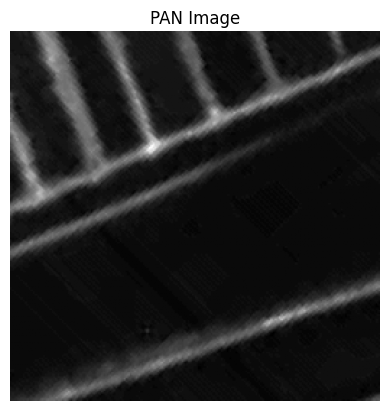

In [6]:
pan = f["PAN_IMAGES"][0]      # Shape: (1, 256, 256)
print(pan[0].shape)                  # Remove the channel dimension
pan = pan[0]
plt.imshow(pan, cmap="gray")
plt.title("PAN Image")
plt.axis("off")
plt.show()

In [7]:
ms = f["MUL_IMAGES"][0]

print(ms.shape)

(4, 64, 64)


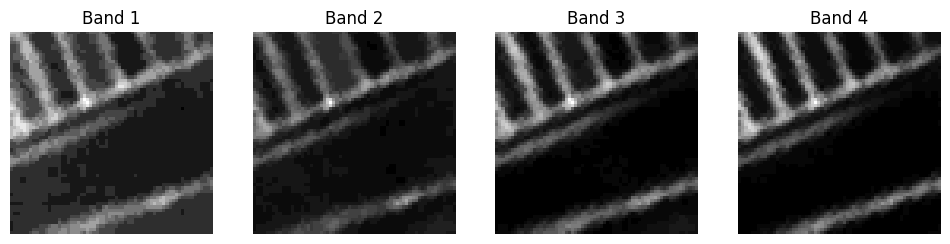

In [8]:
ms = f["MUL_IMAGES"][0]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    axes[i].imshow(ms[i], cmap="gray")
    axes[i].set_title(f"Band {i+1}")
    axes[i].axis("off")

plt.show()

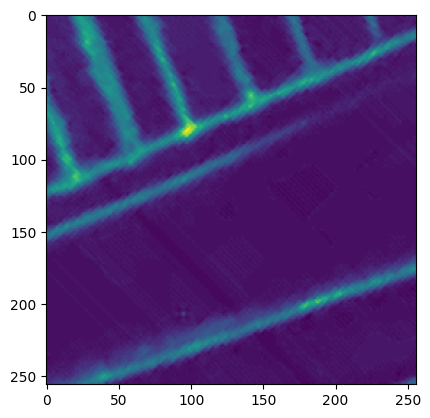

In [9]:
plt.imshow(pan)

In [10]:
labels = f["LAND_COVER_TYPES"][0]

print(labels.shape)
print(labels[:20])

(80000,)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Task 1.2 — Organize & Pair Images

In [11]:
pan = f["PAN_IMAGES"]
ms = f["MUL_IMAGES"]
labels = f["LAND_COVER_TYPES"][0]

In [12]:
print("PAN Images :", len(pan))
print("MS Images  :", len(ms))
print("Labels     :", len(labels))

PAN Images : 80000
MS Images  : 80000
Labels     : 80000


In [13]:
for i in range(3):
    print(f"Sample {i}")
    print("PAN Shape :", pan[i].shape)
    print("MS Shape  :", ms[i].shape)
    print("Label     :", labels[i])


Sample 0
PAN Shape : (1, 256, 256)
MS Shape  : (4, 64, 64)
Label     : 1.0
Sample 1
PAN Shape : (1, 256, 256)
MS Shape  : (4, 64, 64)
Label     : 1.0
Sample 2
PAN Shape : (1, 256, 256)
MS Shape  : (4, 64, 64)
Label     : 1.0


Task 1.3 — Preprocessing

* resize kyun krna hh bhai? -->models (ResNet, ViT, CLIP, etc.) expect a fixed input size.

* normalize ? --> DL model bdiya train hopayega floating points inputs sei. (image = image/255.0)

* dikat yeh hh ki hamra data ka datatype uint8 hh, usko float32 mei convert krna padega

* pixel values ko normalize krna -->225  sei 0-->1

* fir resize: 
pan: 256 X 256 --> 224 X 224
ms: 64 X 64 --> 224 X 224

In [14]:
import torch
from torchvision.transforms import functional as TF

note: we will be using tensors not ndarray, pytorch need tensor

In [15]:
pan = f["PAN_IMAGES"][0]
ms = f["MUL_IMAGES"][0]

In [16]:
print("PAN:", pan.shape)
print("MS :", ms.shape)

PAN: (1, 256, 256)
MS : (4, 64, 64)


converting to torch tensor

In [17]:
pan = torch.tensor(pan,dtype=torch.float32)
ms = torch.tensor(ms,dtype=torch.float32)

now time for normalization(0-->1)

In [18]:
pan = pan/255.0
ms = ms/255.0

In [19]:
print(pan.min(), pan.max())
print(ms.min(), ms.max())

tensor(0.2157) tensor(0.4118)
tensor(0.1333) tensor(0.4510)


resizing

In [20]:
pan = TF.resize(pan, [224, 224])
ms = TF.resize(ms, [224, 224])

In [21]:
print("PAN:", pan.shape)
print("MS :", ms.shape)

PAN: torch.Size([1, 224, 224])
MS : torch.Size([4, 224, 224])


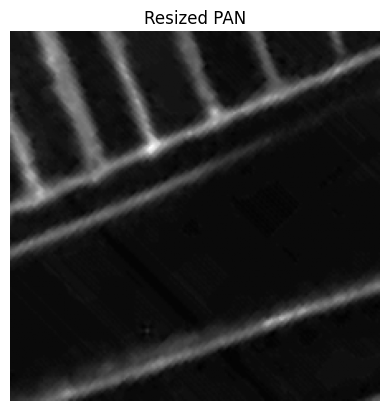

In [22]:
plt.imshow(pan.squeeze(), cmap="gray")
plt.title("Resized PAN")
plt.axis("off")
plt.show()

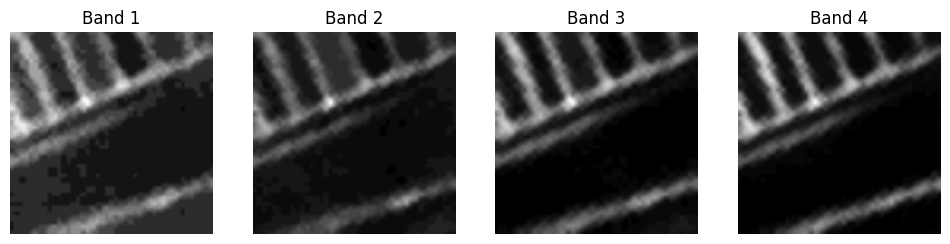

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(12,3))

for i in range(4):
    axes[i].imshow(ms[i], cmap="gray")
    axes[i].set_title(f"Band {i+1}")
    axes[i].axis("off")

plt.show()

note: future porblem

Right now we're preprocessing only one sample (index 0). This is fine for understanding and testing.

In a proper ML pipeline, you don't preprocess all 80,000 images manually. Instead, you'll apply these same steps inside a custom PyTorch Dataset class (Task 1.5), so every image is automatically preprocessed when it's loaded.

So for now, completing Task 1.3 on one sample is a good way to verify that your preprocessing works before integrating it into the dataset loader.

Task 1.4 — Split Dataset(soon)

* training set --> used to train model
* validation set --> used to fine tune the model
* test set--> used for final testing and reviewing the model


note: we split indices not the image themselves. kyoki agar pan and ms images separte hogye agar humne images ko separte krdiya toh hum pairing nhi krpayenge or comapre nhi krapayeneg ms and pan images ko toh indices is better option.

In [24]:
from sklearn.model_selection import train_test_split
import numpy as np

In [25]:
labels = np.array(f["LAND_COVER_TYPES"][0])
labels.shape

(80000,)

In [26]:
len(labels)

80000

In [27]:
indices = np.arange(len(labels))

print(indices[:10])

[0 1 2 3 4 5 6 7 8 9]


In [28]:
#spliting 
train_idx, temp_idx = train_test_split(
    indices,
    test_size= 0.2,#20% data --> temp_idx
    random_state=42,#make the split reproducible
    stratify= labels#preserve class distrib during the splits
)

In [29]:
# validation/test split
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=labels[temp_idx]
)

In [30]:
print("Training Samples   :", len(train_idx))
print("Validation Samples:", len(val_idx))
print("Testing Samples   :", len(test_idx))

Training Samples   : 64000
Validation Samples: 8000
Testing Samples   : 8000


In [31]:
sample = train_idx[0]
print("Index:", sample)

Index: 69679


In [32]:
print("PAN Shape :", f["PAN_IMAGES"][sample].shape)
print("MS Shape  :", f["MUL_IMAGES"][sample].shape)
print("Label     :", labels[sample])

PAN Shape : (1, 256, 256)
MS Shape  : (4, 64, 64)
Label     : 7.0


In [33]:
print(labels.dtype)
print(np.unique(labels))

float64
[1. 2. 3. 4. 5. 6. 7. 8.]


In [34]:
unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {int(u)} : {c} samples")

Class 1 : 10000 samples
Class 2 : 10000 samples
Class 3 : 10000 samples
Class 4 : 10000 samples
Class 5 : 10000 samples
Class 6 : 10000 samples
Class 7 : 10000 samples
Class 8 : 10000 samples


Task 1.5 – Create a Custom PyTorch Dataset

covert -->tensor--> resize
64l training imgs hn, yoh ek ek k liye krna impossible hh, toh pytorch does evrything automatically

In [35]:
import torch
from torchvision.transforms import functional as TF
from torch.utils.data import Dataset

In [36]:
class DSRSIDDataset(Dataset):

    def __init__(self, pan_images, ms_images, labels, indices):
        self.pan_images = pan_images
        self.ms_images = ms_images
        self.labels = labels
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        # Get actual dataset index
        index = self.indices[idx]

        # Load PAN image, MS image, and label
        pan = self.pan_images[index]
        ms = self.ms_images[index]
        label = self.labels[index]

        # Convert to PyTorch tensors and normalize
        pan = torch.from_numpy(pan).float() / 255.0
        ms = torch.from_numpy(ms).float() / 255.0

        # Resize images
        pan = TF.resize(pan, [224, 224])
        ms = TF.resize(ms, [224, 224])

        # Convert labels from 1-8 to 0-7
        label = int(label) - 1

        return pan, ms, torch.tensor(label, dtype=torch.long)

Task 1.6 – Create DataLoaders

dataloader: neural net dont train on one image at a time. they train on batches.

In [37]:
from torch.utils.data import DataLoader

In [38]:
train_dataset = DSRSIDDataset(
    pan_images=f["PAN_IMAGES"],
    ms_images=f["MUL_IMAGES"],
    labels=labels,
    indices=train_idx
)

val_dataset = DSRSIDDataset(
    pan_images=f["PAN_IMAGES"],
    ms_images=f["MUL_IMAGES"],
    labels=labels,
    indices=val_idx
)

test_dataset = DSRSIDDataset(
    pan_images=f["PAN_IMAGES"],
    ms_images=f["MUL_IMAGES"],
    labels=labels,
    indices=test_idx
)

In [39]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [40]:
pan_batch, ms_batch, label_batch = next(iter(train_loader)) #tst the dataloader

In [41]:
print("PAN Batch Shape :", pan_batch.shape)
print("MS Batch Shape  :", ms_batch.shape)
print("Label Shape     :", label_batch.shape)

PAN Batch Shape : torch.Size([32, 1, 224, 224])
MS Batch Shape  : torch.Size([32, 4, 224, 224])
Label Shape     : torch.Size([32])


In [42]:
for pan, ms, label in train_loader:
    print(pan.shape)
    break


torch.Size([32, 1, 224, 224])


Task 2.1
* PAN Encoder
* Forward Pass
* Output Shape Verified

In [43]:
import torch
import torch.nn as nn

In [44]:
nn.Conv2d(
    in_channels=1,
    out_channels=32,
    kernel_size=3
)

Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))

In [45]:
class PANEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(
            in_features=64*56*56,
            out_features=128
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)

        x = self.fc(x)

        return x

In [46]:
pan_encoder = PANEncoder()

In [47]:
pan_batch, ms_batch, labels = next(iter(train_loader))

In [48]:
output = pan_encoder(pan_batch)

In [49]:
print(output.shape)

torch.Size([32, 128])


Task 2.2 - MS Encoder

In [50]:
import torch
import torch.nn as nn

class MSEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(4, 32, 3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2,2)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64*56*56,128)

    def forward(self,x):

        x=self.conv1(x)
        x=self.relu1(x)
        x=self.pool1(x)

        x=self.conv2(x)
        x=self.relu2(x)
        x=self.pool2(x)

        x=self.flatten(x)
        x=self.fc(x)

        return x

In [51]:
ms_encoder = MSEncoder()

In [52]:
output = ms_encoder(ms_batch)
print(output.shape)

torch.Size([32, 128])


task 2.3 - Dual Encoder

In [53]:
class DualEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.pan_encoder = PANEncoder()

        self.ms_encoder = MSEncoder()

    def forward(self, pan, ms):
        pan_embedding = self.pan_encoder(pan)
        ms_embedding = self.ms_encoder(ms)

        return pan_embedding, ms_embedding

In [54]:
model = DualEncoder()
pan_embedding, ms_embedding = model(
    pan_batch,
    ms_batch
)

In [55]:
pan_embedding.shape

torch.Size([32, 128])

In [56]:
ms_embedding.shape

torch.Size([32, 128])

task 2.4-loss func

* agr pan and ms same location ke hain --> embedd. close honi chaiyen

* agar diff location k hein --> embedd. far hone chaiyen
that's the work of loss func

In [57]:
import torch.nn as nn

In [58]:
criterion = nn.CosineEmbeddingLoss(margin=0.5)

* targeting labels -  cosineembeddingloss ko target bhi chaiyen.

rule: same pair --> +1
 if differnet pair --> -1

aab hamara dataloader sirf mactching pairs dega

In [59]:
target = torch.ones(pan_embedding.size(0))

In [60]:
target

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

* now have to calculate loss

In [61]:
loss = criterion(pan_embedding,ms_embedding,target)

In [62]:
loss.item()

0.9066822528839111

## DATA FLOW

* pan image -> pan encoder -> pan embedding -> cosine embedding loss -> ms encoder -> ms image

Task 2.5 - optimizer

* to reduce the loss we need to update the CNN weights after every backward pass to reduce the loss


why do we need an optimizer??
* imagine a loss func is: loss = 1.25,
the model doesn't know how to reduce it

* the optimizer decide:
--> which weights should change and how much, 
without an optimizer, the model never learns.

In [63]:
import torch.optim as optim

In [64]:
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)
    # lr: float | Tensor = 0.001,
    # it's learning rate: it controls how big a step the opt. takes


what does this mean?
* my encoder contains:
 * -> Dualencoder 
* |
*  panencoder
 *  |   |__ conv1
 *   |   |__ conv2
  * |  |__ fc
  * |
  * |__Msencoder
   *       |__conv1
    *      |__conv2
   *       |__fc

* every conv2d and linear layer has weights.
model.parameters() collects all trainable weights from both encoders.



task 2.6- learning loop(to be continued..)

In [72]:
num_epochs = 2

for epoch in range(num_epochs):
    print(f"\n Epoch {epoch+1}")

    for pan_batch,ms_batch,labels in train_loader:

        print(pan_batch.shape)

        break


 Epoch 1
torch.Size([32, 1, 224, 224])

 Epoch 2
torch.Size([32, 1, 224, 224])


In [73]:
num_epochs =1

for epoch in range(num_epochs):
    batch_no = 0

    for pan_batch,ms_batch,labels in train_loader:
        batch_no +=1

        print(f"Batch {batch_no}")

        if batch_no ==5:
            break

Batch 1
Batch 2
Batch 3
Batch 4
Batch 5


taraining loop image processing then step by step Batch

↓

Forward Pass

↓

Loss

↓

Backward Pass

↓

Optimizer Step

In [76]:
#adding forward pass

for epoch in range(num_epochs):
    batch_no = 0

    for pan_batch,ms_batch,labels in train_loader:

        batch_no+=1

        pan_embedding,ms_embedding = model(
            pan_batch,
            ms_batch
        )

        # print(pan_embedding.shape)
        # print(ms_embedding.shape)
        print(f"Batch {batch_no}: Loss = {loss.item():.4f}")
        #adding loss
        target = torch.ones(pan_embedding.size(0) )

        loss = criterion(pan_embedding,ms_embedding,target)
        print(loss.item())

        optimizer.zero_grad()#stores old gradients. this clear them before the next batch

        loss.backward()#backprop.

        optimizer.step()#update weights
        if batch_no == 5:
            break

Batch 1: Loss = 0.8372
0.728274405002594
Batch 2: Loss = 0.7283
0.569503903388977
Batch 3: Loss = 0.5695
0.3979533910751343
Batch 4: Loss = 0.3980
0.22441112995147705
Batch 5: Loss = 0.2244
0.08178495615720749


har batch ke liye model embeddings bana raha hai.

Task 2.7 — Validation Loop

In [78]:
model.eval()

val_loss = 0

with torch.no_grad():

    for pan_batch,ms_batch,labels in val_loader:

        pan_embedding,ms_embedding =model(pan_batch,ms_batch)

        target = torch.ones(
            pan_embedding.size(0)
        )

        loss = criterion(pan_embedding,ms_embedding,target)

        val_loss += loss.item()

    avg_val_loss = val_loss/len(val_loader)

    print(f" validation loss: {avg_val_loss:.4f}")

KeyboardInterrupt: 

locally running on my pc with low spec so it's currently taking more time i will switch to the colab later.


In [79]:
model.eval()

val_loss = 0

with torch.no_grad():

    for i, (pan_batch, ms_batch, labels) in enumerate(val_loader):

        pan_embedding, ms_embedding = model(
            pan_batch,
            ms_batch
        )

        target = torch.ones(
            pan_embedding.size(0)
        )

        loss = criterion(
            pan_embedding,
            ms_embedding,
            target
        )

        val_loss += loss.item()

        if i % 50 == 0:
            print(f"Processed {i} batches")

avg_val_loss = val_loss / len(val_loader)

print(f"Validation Loss: {avg_val_loss:.4f}")

Processed 0 batches
Processed 50 batches
Processed 100 batches
Processed 150 batches
Processed 200 batches
Validation Loss: 0.0247


# new conceps

1. model.eval(): thia switch model to evaluation mode.
* It is important because layers like:

Dropout
BatchNorm

behave differently during training and testing.

Your current model does not use them, but it is still standard practice.


2. with torch.no_grad():This tells PyTorch:"Don't compute gradients."

3. avg_val_loss = val_loss / len(val_loader)

* Instead of looking at the loss of one batch, we compute the average loss across the whole validation set.